# 04 — Ecology reference specifications

Four small reference figures for the manuscript, rendered with R from
the exact inputs the experiment uses: the committed synthetic climate
netCDFs (`../data/`) and the growth-equation primitives in
[`harness/spec_model.py`](../harness/spec_model.py). They are deliberately
tiny (~2.5 in wide) so they sit inline in the paper as spec callouts.

1. **Spatial inputs** (single time slice, *not* across time):
   - `eco_temp_spatial` — temperature (K) across the grid.
   - `eco_precip_spatial` — precipitation (mm/yr) across the grid.
2. **Growth-response domains** (the math, not the data):
   - `eco_temp_domain` — the parabolic temperature response %_T(T).
   - `eco_precip_domain` — the logistic precipitation response %_P(P),
     overlaid for three *drought-floor* settings. The floor is the
     minimum precipitation impact: at a 0% floor a total drought yields
     0% of otherwise-possible growth; at a 90% floor the same drought
     still yields 90%. The overlay motivates how raising the lower bound
     on precip impact would soften the simulation's drought penalty.

All four are saved to `figures/` as both PNG (the requested deliverable)
and PDF (the vector form the other manuscript figures use).

In [1]:
# Inline-plot sizing for IRkernel; each plotting cell stays small.
options(repr.plot.width = 4, repr.plot.height = 3, repr.plot.res = 150)

suppressPackageStartupMessages({
  library(ncdf4)   # read the synthetic climate netCDFs
  library(dplyr)
  library(tidyr)
  library(tibble)
  library(ggplot2)
  library(scales)
})

# Lato (analysis/fonts/, OFL) — same font wiring as 01_analysis.ipynb.
# showtext draws text as paths via freetype, so no fontconfig install is
# needed; dpi here must match the ggsave dpi so text is sized correctly.
library(showtext)
font_add("Lato",
         regular    = "fonts/Lato-Regular.ttf",
         bold       = "fonts/Lato-Bold.ttf",
         italic     = "fonts/Lato-Italic.ttf",
         bolditalic = "fonts/Lato-BoldItalic.ttf")
showtext_auto()
showtext_opts(dpi = 300)

# Spec constants — mirror harness/spec_model.py, the single source of
# truth shared by the reference simulator and the scorer. Keep in sync.
T_MIN <- 270.0; T_MAX <- 330.0
P_LOW <- 300.0; P_HIGH <- 500.0; P_K <- 12.0
SECONDS_PER_YEAR <- 31536000   # kg m-2 s-1 -> mm/yr
REF_YEAR <- 2024               # first simulated year; the single time slice

OUT_DIR <- "figures"
dir.create(OUT_DIR, showWarnings = FALSE)

# Small-figure theme: tuned to read clearly at thumbnail size in the paper.
# base = 10 keeps the labels chunky relative to the tiny figure footprint.
theme_ref <- function(base = 10) {
  theme_minimal(base_size = base, base_family = "Lato") +
    theme(
      plot.title        = element_text(face = "bold", size = base),
      axis.text         = element_text(size = base - 2),
      legend.title      = element_text(size = base - 1),
      legend.text       = element_text(size = base - 1),
      legend.key.width  = unit(0.5, "lines"),
      legend.key.height = unit(0.5, "lines"),
      plot.margin       = margin(4, 8, 2, 2)
    )
}

# At this size dense ticks crowd the big labels. Thin every axis to three
# breaks — min, midpoint, max — and lean on scale expansion for breathing
# room. `three_breaks` plugs into any continuous scale's `breaks` arg.
three_breaks <- function(limits) c(limits[1], mean(limits), limits[2])
SPACE <- expansion(mult = 0.04)   # a little air around the data

# Default small figure size (inches). The external-data maps are narrower
# (colourbar moves underneath); the precip curve keeps its legend on-figure.
W <- 2.6; H <- 2.2

# Save both PNG (requested deliverable) and PDF (manuscript vector form).
save_fig <- function(plot, stem, width = W, height = H) {
  ggsave(file.path(OUT_DIR, paste0(stem, ".png")), plot,
         width = width, height = height, dpi = 300)
  ggsave(file.path(OUT_DIR, paste0(stem, ".pdf")), plot,
         width = width, height = height)
  invisible(plot)
}

Loading required package: sysfonts



Loading required package: showtextdb



## 1. Spatial inputs (single time slice)

The two forcings are *separable*: temperature varies north–south (latitude),
precipitation east–west (longitude). We take one year (`REF_YEAR`) so the
figures show only the spatial structure, not the warming trend.

In [2]:
# Read one (lat, lon) slice for REF_YEAR. ncvar_get returns the array
# fastest-axis-first, i.e. (lon, lat, calendar_year), so we slice the
# year axis and tidy to long form.
read_field <- function(path, var) {
  nc <- nc_open(path); on.exit(nc_close(nc))
  arr <- ncvar_get(nc, var)                 # (lon, lat, calendar_year)
  lon <- ncvar_get(nc, "lon")
  lat <- ncvar_get(nc, "lat")
  yrs <- ncvar_get(nc, "calendar_year")
  slab <- arr[, , match(REF_YEAR, yrs)]     # (lon, lat)
  dimnames(slab) <- list(lon = lon, lat = lat)
  as.data.frame(as.table(slab)) |>
    transmute(lon = as.numeric(as.character(lon)),
              lat = as.numeric(as.character(lat)),
              value = Freq)
}

temp_sp <- read_field("../data/maxtemp_synthetic.nc", "tasmax")
prec_sp <- read_field("../data/precip_synthetic.nc", "pr") |>
  mutate(value = value * SECONDS_PER_YEAR)  # kg m-2 s-1 -> mm/yr

cat(sprintf("temp K:    %.1f - %.1f\n", min(temp_sp$value), max(temp_sp$value)))
cat(sprintf("precip mm/yr: %.1f - %.1f\n", min(prec_sp$value), max(prec_sp$value)))

# Josh runs the spec on 16 km square patches; overlay a generic grid at that
# spacing for illustration (NOT aligned to the native cells). 16 km in degrees:
# lat is ~constant; lon is scaled by cos(lat).
PATCH_KM       <- 16
KM_PER_DEG_LAT <- 110.574
KM_PER_DEG_LON <- 111.320   # * cos(lat), applied below

# External-data maps: three axis breaks (corner coords, 0.1-deg labels so
# they don't crowd) and a colourblind-safe viridis fill. The colourbar sits
# UNDERNEATH the map, turned sideways (horizontal), so the figure stays narrow.
# No coord_fixed — the raster fills the narrow width; the gradient direction
# is the point, not the geographic aspect ratio. Extra x-expansion + right
# margin keep the outer corner labels from clipping the figure edge. Axis
# titles and the colourbar title are dropped — units live in the plot title.
# White lines show the 16 km patch grid against both dark and light fills.
spatial_plot <- function(d, title, option = "viridis") {
  lonr <- range(d$lon); latr <- range(d$lat)
  dlat <- PATCH_KM / KM_PER_DEG_LAT
  dlon <- PATCH_KM / (KM_PER_DEG_LON * cos(mean(latr) * pi / 180))
  vlines <- seq(lonr[1], lonr[2], by = dlon)
  hlines <- seq(latr[1], latr[2], by = dlat)

  ggplot(d, aes(lon, lat, fill = value)) +
    geom_tile() +
    geom_vline(xintercept = vlines, colour = "white", linewidth = 0.35) +
    geom_hline(yintercept = hlines, colour = "white", linewidth = 0.35) +
    scale_x_continuous(breaks = three_breaks,
                       labels = label_number(accuracy = 0.1),
                       expand = expansion(mult = 0.09)) +
    scale_y_continuous(breaks = three_breaks,
                       labels = label_number(accuracy = 0.1), expand = SPACE) +
    scale_fill_viridis_c(
      option = option, name = NULL,
      breaks = three_breaks, labels = label_number(accuracy = 1),
      guide = guide_colourbar(direction = "horizontal",
                              barwidth = unit(6, "lines"),
                              barheight = unit(0.4, "lines"))) +
    labs(title = title, x = NULL, y = NULL) +
    theme_ref() +
    theme(legend.position = "bottom",
          legend.margin = margin(0, 0, 0, 0),
          legend.box.spacing = unit(2, "pt"),
          plot.margin = margin(4, 12, 2, 2),
          panel.grid = element_blank())   # the white 16 km grid is the only grid
}

temp K:    283.9 - 315.9


precip mm/yr: 152.6 - 617.5


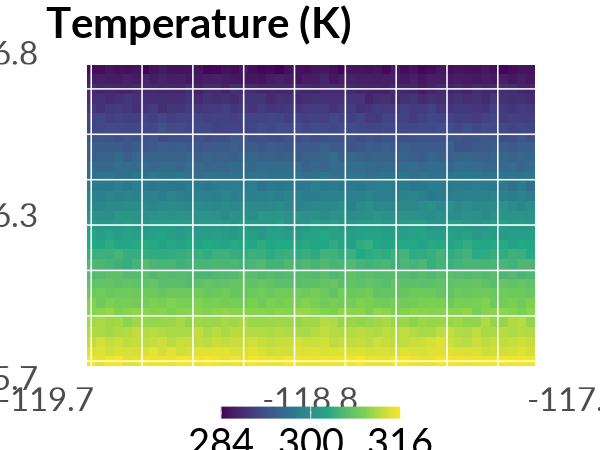

In [3]:
# Latitude gradient: warm south -> cool north. Viridis (default ramp).
# Narrow footprint; colourbar underneath (set in spatial_plot).
p_temp <- spatial_plot(temp_sp, "Temperature (K)", option = "viridis")
save_fig(p_temp, "eco_temp_spatial", width = 2.0, height = 2.1)
p_temp

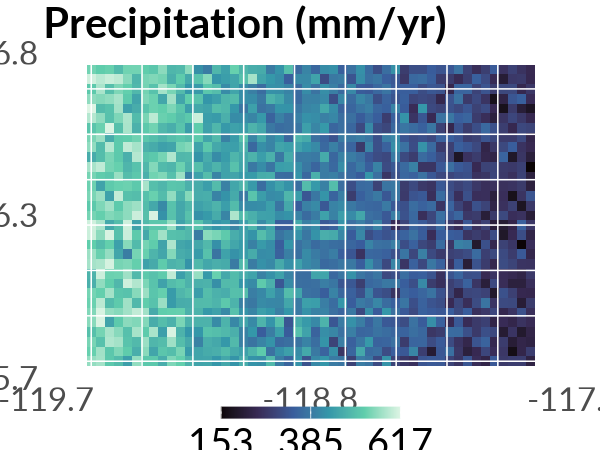

In [4]:
# Longitude gradient: wet west -> dry east. Mako (blue-family viridis) reads
# as "water" while staying colourblind-safe and distinct from the temp map.
p_prec <- spatial_plot(prec_sp, "Precipitation (mm/yr)", option = "mako")
save_fig(p_prec, "eco_precip_spatial", width = 2.0, height = 2.1)
p_prec

## 2. Growth-response domains (the math)

The per-year growth multipliers from
[`harness/spec_model.py`](../harness/spec_model.py):

- **Temperature** — parabolic, peaking at the optimum and clamped to
  zero outside `[T_min, T_max]`: %_T = 4·x·(1−x), x = (T−T_min)/(T_max−T_min).
- **Precipitation** — logistic in P: %_P = 1 / (1 + exp(−k·(x−0.5))),
  x = (P−P_low)/(P_high−P_low).

The precipitation panel overlays a **drought floor** `f` applied as
`f + (1−f)·%_P`, so the response can never drop below `f`. At `f = 0%`
a total drought zeroes growth; at `f = 90%` the same drought still allows
90%. This is the lower-bound knob whose effect on the simulation we want
to motivate.

In [5]:
# Response functions — byte-faithful to harness/spec_model.py.
temp_impact <- function(T) {
  x <- pmin(pmax((T - T_MIN) / (T_MAX - T_MIN), 0), 1)
  4 * x * (1 - x)
}
precip_impact <- function(P) {
  x <- (P - P_LOW) / (P_HIGH - P_LOW)
  1 / (1 + exp(-P_K * (x - 0.5)))
}

# Light grid helps read these curves at small size.
theme_curve <- function() {
  theme_ref() +
    theme(panel.grid.major = element_line(linewidth = 0.2, colour = "grey90"),
          panel.grid.minor = element_blank())
}

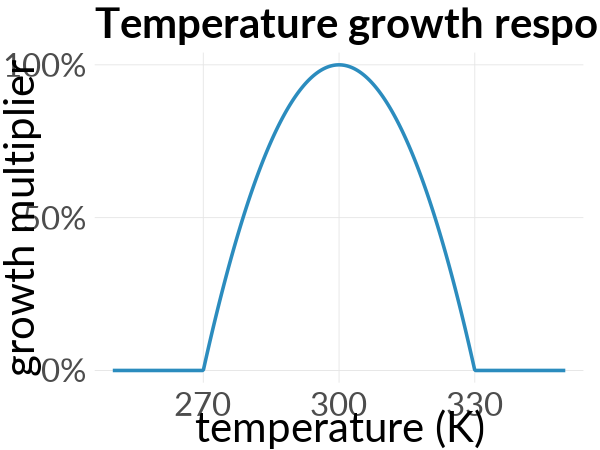

In [6]:
# Pad the domain past [T_min, T_max] so the clamp is visible: temp_impact
# clips x to [0, 1], so the response sits flat at 0 outside the window.
T_PAD <- 20
tdom <- tibble(T = seq(T_MIN - T_PAD, T_MAX + T_PAD, length.out = 500)) |>
  mutate(impact = temp_impact(T))

p_tdom <- ggplot(tdom, aes(T, impact)) +
  geom_line(colour = "#2b8cbe", linewidth = 0.8) +
  # Breaks mark the two clamp boundaries and the optimum, not the padded edges.
  scale_x_continuous(breaks = c(T_MIN, (T_MIN + T_MAX) / 2, T_MAX), expand = SPACE) +
  scale_y_continuous(breaks = c(0, 0.5, 1), limits = c(0, 1),
                     labels = percent_format(accuracy = 1), expand = SPACE) +
  labs(title = "Temperature growth response",
       x = "temperature (K)", y = "growth multiplier") +
  theme_curve()
save_fig(p_tdom, "eco_temp_domain")
p_tdom

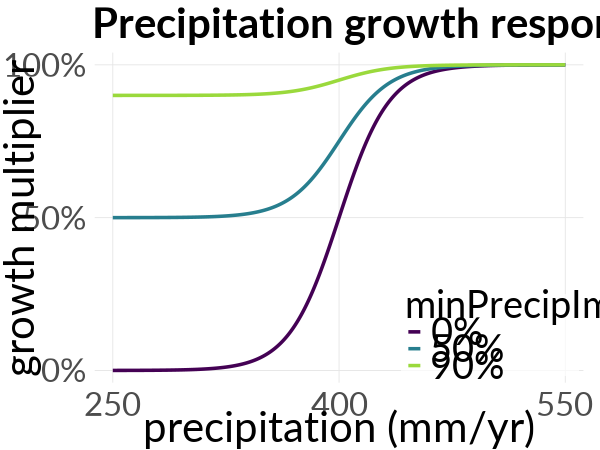

In [7]:
# Three drought floors: f + (1 - f) * logistic(P). Domain runs a little
# past [P_low, P_high] so both shoulders of the sigmoid are visible. The
# floor is `minPrecipImpactPct` in the Josh config — the name the legend uses.
floors <- c(0.0, 0.5, 0.9)
floor_levels <- percent(floors, accuracy = 1)
P_MIN <- P_LOW - 50; P_MAX <- P_HIGH + 50

pdom <- expand_grid(P = seq(P_MIN, P_MAX, length.out = 400), floor = floors) |>
  mutate(impact    = floor + (1 - floor) * precip_impact(P),
         floor_lab = factor(percent(floor, accuracy = 1), levels = floor_levels))

p_pdom <- ggplot(pdom, aes(P, impact, colour = floor_lab)) +
  geom_line(linewidth = 0.8) +
  scale_x_continuous(breaks = c(P_MIN, (P_MIN + P_MAX) / 2, P_MAX), expand = SPACE) +
  scale_y_continuous(breaks = c(0, 0.5, 1), limits = c(0, 1),
                     labels = percent_format(accuracy = 1), expand = SPACE) +
  # Viridis discrete (colourblind-safe); ordered low->high floor. `end = 0.85`
  # trims the brightest yellow so the top line stays visible on white.
  scale_colour_viridis_d(end = 0.85, name = "minPrecipImpactPct") +
  labs(title = "Precipitation growth response",
       x = "precipitation (mm/yr)", y = "growth multiplier") +
  theme_curve() +
  # Legend on-figure in the empty bottom-right (curves are saturated there),
  # so no side gutter is needed and the figure stays as narrow as the others.
  theme(legend.position = "inside",
        legend.position.inside = c(0.99, 0.02),
        legend.justification = c(1, 0),
        legend.background = element_rect(fill = alpha("white", 0.7), colour = NA),
        legend.key = element_blank(),
        legend.margin = margin(1, 3, 1, 3))
save_fig(p_pdom, "eco_precip_domain")
p_pdom